# GROUP1 : Peak Transformers

# Uploading the dataset into Kaggle environment

In [193]:
import numpy as np 
import pandas as pd # data processing, CSV file 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hiswishchaka/heckdata/Synthetic_Financial_Datasets_For_Fraud_Detection_resample.csv


# READING IN THE DATASET

In [194]:
df = pd.read_csv(
'/kaggle/input/datasets/hiswishchaka/heckdata/Synthetic_Financial_Datasets_For_Fraud_Detection_resample.csv')

In [195]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,182,CASH_IN,100328.70,C197678862,3389602.37,3489931.07,C386191921,219735.14,119406.44,0,0
1,210,PAYMENT,11660.99,C2009511954,94054.00,82393.01,M564284134,0.00,0.00,0,0
2,403,CASH_IN,230751.30,C1132312861,23117012.10,23347763.39,C1025694734,951294.81,720543.51,0,0
3,328,PAYMENT,17833.60,C1191709365,0.00,0.00,M293024801,0.00,0.00,0,0
4,563,CASH_OUT,246476.67,C342438889,0.00,0.00,C2087488957,4226850.16,4473326.82,0,0


In [196]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
636257,325,CASH_OUT,193812.50,C425986045,95438.0,0.00,C1813421380,511348.22,705160.72,0,0
636258,324,PAYMENT,71240.51,C246016542,5021.0,0.00,M332903748,0.00,0.00,0,0
636259,231,CASH_IN,219467.05,C152812322,3990.0,223457.05,C316565040,2593190.49,2373723.44,0,0
636260,306,PAYMENT,1048.54,C37754145,0.0,0.00,M1903551785,0.00,0.00,0,0
636261,351,CASH_OUT,183470.05,C666430536,109435.0,0.00,C1377586611,0.00,183470.05,0,0


In [197]:
df['isFlaggedFraud'].unique()

array([0, 1])

# Checking Missing values

In [198]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# Checking duplicates

****this is for checking if there some individuals with multiple transactions***

In [199]:
# check duplicates in the nameOrig column
df["nameOrig"].duplicated().sum()

np.int64(95)

In [200]:
#check duplicates in the nameDest column
df["nameDest"].duplicated().sum()

np.int64(178857)

In [201]:
# How many times does each destination account appear?
dest_counts = df["nameDest"].value_counts()
print(dest_counts.head(10))  # most frequently appearing recipients



nameDest
C2083562754    29
C1652369868    14
C451111351     14
C1360767589    14
C1286084959    14
C1590550415    14
C184253187     13
C863811613     13
C1261031890    13
C2049813033    13
Name: count, dtype: int64


# Summary Statistics

In [202]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,636262.000000,6.362620e+05,6.362620e+05,6.362620e+05,6.362620e+05,6.362620e+05,636262.000000,636262.000000
mean,243.603050,1.801858e+05,8.356350e+05,8.566696e+05,1.105524e+06,1.230272e+06,0.001334,0.000003
std,142.142473,6.136135e+05,2.893755e+06,2.929387e+06,3.447599e+06,3.724619e+06,0.036504,0.001773
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,156.000000,1.342490e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,239.000000,7.460482e+04,1.423100e+04,0.000000e+00,1.336986e+05,2.154826e+05,0.000000,0.000000
75%,334.000000,2.081028e+05,1.075470e+05,1.446871e+05,9.486479e+05,1.117370e+06,0.000000,0.000000
max,743.000000,7.382349e+07,5.039905e+07,4.367380e+07,3.551855e+08,3.553805e+08,1.000000,1.000000


1. ***The transaction amounts are highly variable and positively skewed.***
2. ***The average transaction amount is approximately 181,858, while the median is only 74,605.***
3. ***The mean of the isFraud variable is 0.001334, meaning that only about 0.13% of the transactions are fraudulent. This      indicates that the dataset is highly imbalanced, with legitimate transactions vastly outnumbering fraudulent ones.***

In [203]:
# analysing the rows and columns of the dataset
df.shape

(636262, 11)

# Checking Class Imbalance on the Target variable

In [204]:
# counting values per category (non_fraud, fraud)
print(df['isFraud'].value_counts())

# calculating Percentages,
print()
print(df["isFraud"].value_counts(normalize=True) * 100)


isFraud
0    635413
1       849
Name: count, dtype: int64

isFraud
0    99.866564
1     0.133436
Name: proportion, dtype: float64


In [205]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    636260
1         2
Name: count, dtype: int64

In [206]:
# Importing libraries for data visualizations
import matplotlib.pyplot as plt
import seaborn as sns

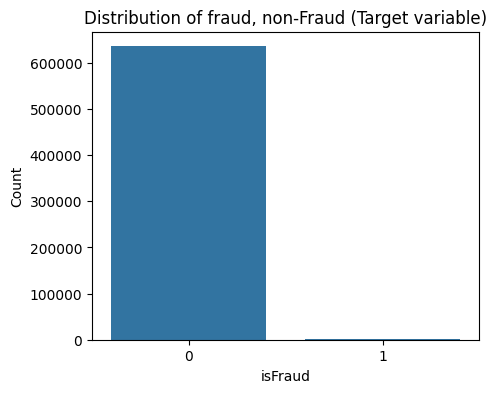

In [207]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Distribution of fraud, non-Fraud (Target variable)")
plt.xlabel('isFraud')
plt.ylabel("Count")
plt.show()

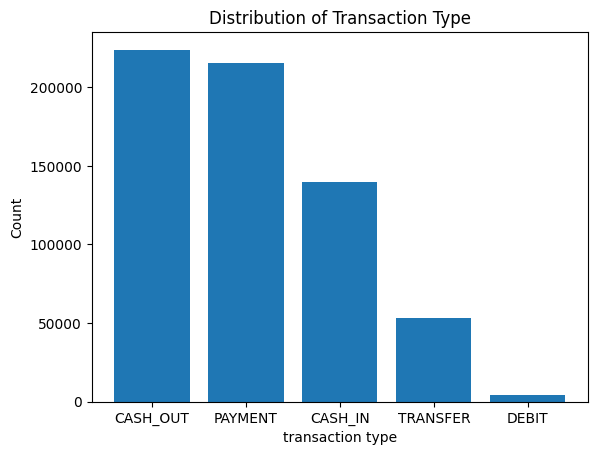

In [208]:
counts = df['type'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Distribution of Transaction Type")
plt.xlabel("transaction type")
plt.ylabel("Count")
plt.show()

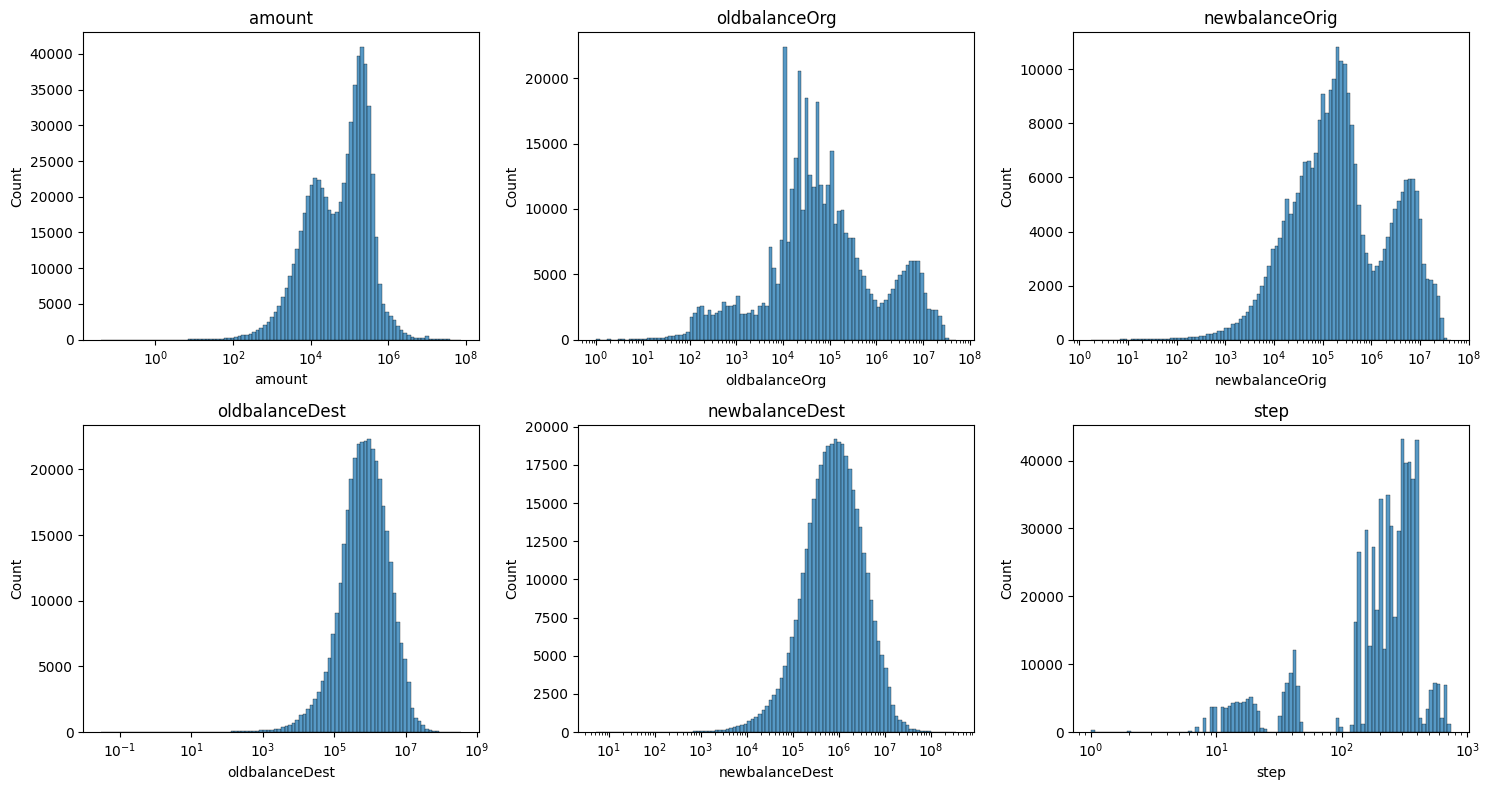

In [209]:
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "step"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=100, ax=axes[i], log_scale=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

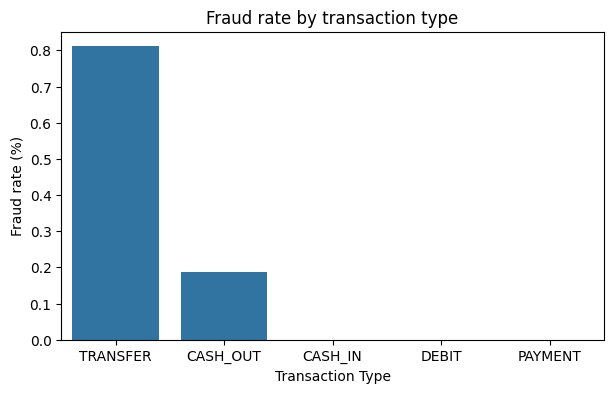

In [210]:
# Fraud rate by transaction type 
fraud_rate_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 4))
sns.barplot(x=fraud_rate_by_type.index, y=fraud_rate_by_type.values)
plt.xlabel("Transaction Type")
plt.ylabel("Fraud rate (%)")
plt.title("Fraud rate by transaction type")
plt.show()

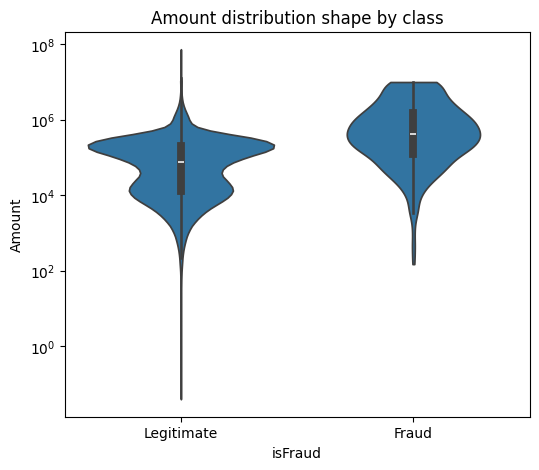

In [211]:
# A violin Plot that shows the distribution of Fraud, non-Fraud vs Amount
plt.figure(figsize=(6, 5))
sns.violinplot(data=df[df["amount"] > 0], x="isFraud", y="amount", log_scale=True, cut=0)
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Amount distribution shape by class")
plt.xlabel("isFraud")
plt.ylabel("Amount")
plt.show()

***From the violin plot, we see that Fraud is associated with large amounts of money being transferred***
***Whereas Legitimate transactions are associated with smaller amounts***

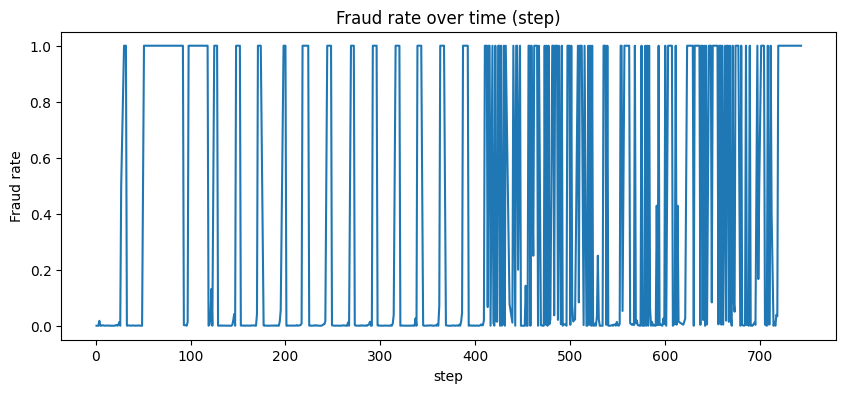

In [212]:
# Distribution of Fraud Rate Over a period of time
fraud_by_step = df.groupby("step")[fraud_col].mean()
plt.figure(figsize=(10, 4))
fraud_by_step.plot()
plt.title("Fraud rate over time (step)")
plt.ylabel("Fraud rate")
plt.show()

# Feature Engeneering

In [213]:
# Fraudulent transfers/cash-outs often drain the origin account (new balance -> 0)
df["orig_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_diff"] = df["newbalanceDest"] - df["oldbalanceDest"]


df["orig_emptied"] = (df["newbalanceOrig"] == 0) & (df["oldbalanceOrg"] > 0)
df["dest_was_empty"] = (df["oldbalanceDest"] == 0) & (df["newbalanceDest"] == 0)

print("Share of transactions where the origin account is emptied, by class:")
print(df.groupby(fraud_col)["orig_emptied"].mean())


Share of transactions where the origin account is emptied, by class:
isFraud
0    0.238506
1    0.972909
Name: orig_emptied, dtype: float64


***From the results, we see that about 97% of fraudulent transactions drain the origin account to zero***

# Correlation matrix for numerical columns

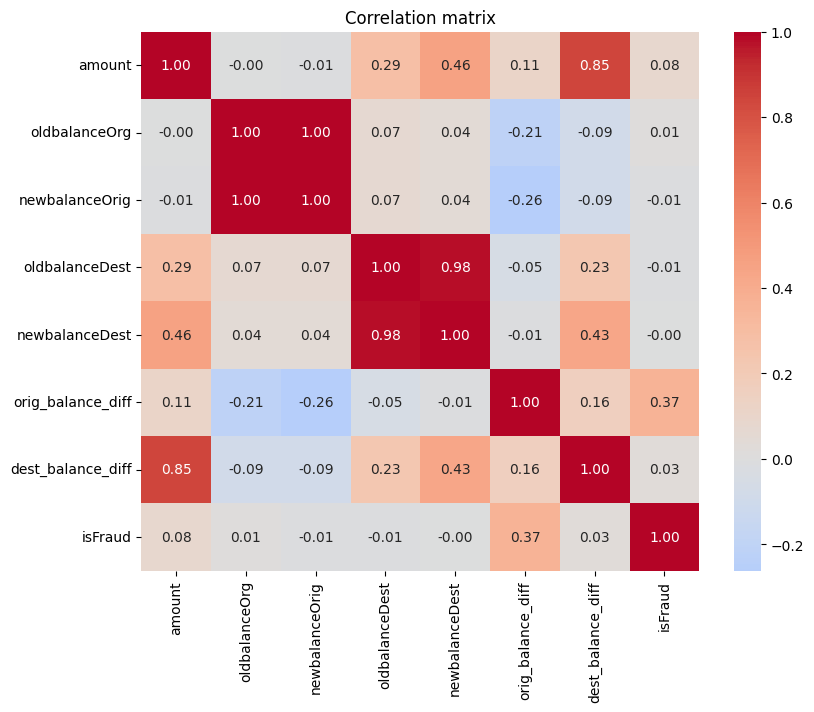

In [214]:
# creating a list of numerical columns
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest",
                "newbalanceDest", "orig_balance_diff", "dest_balance_diff", fraud_col]

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

The correlation matrix reveals three pairs of highly correlated features: oldbalanceOrg and newbalanceOrig (r = 1.00), oldbalanceDest and newbalanceDest (r = 0.98), and amount and dest_balance_diff (r = 0.85). These strong correlations indicate potential multicollinearity, as the variables contain similar information. Regarding the target variable (isFraud), orig_balance_diff shows the strongest positive correlation (r = 0.37), while the remaining features indicate weak linear relationships with fraud, suggesting that fraud detection may depend on complex, non-linear interactions rather than simple linear associations.

In [215]:
#Checking categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['type', 'nameOrig', 'nameDest']


# Data Preprocessing

In [216]:
#creating a copy of the original dataset
df1 = df.copy()


In [217]:
# Dropping identifier columns from the dataset because our model might just memorise the IDs instead of learning the true characteristics of the data
#They do not help the model learn patterns
# Removing these columns allows the model to focus on features that are genuinely related to the prediction task

df1 = df1.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis =1)
df1.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff,orig_emptied,dest_was_empty
0,182,CASH_IN,100328.70,3389602.37,3489931.07,219735.14,119406.44,0,-100328.70,-100328.70,False,False
1,210,PAYMENT,11660.99,94054.00,82393.01,0.00,0.00,0,11660.99,0.00,False,True
2,403,CASH_IN,230751.30,23117012.10,23347763.39,951294.81,720543.51,0,-230751.29,-230751.30,False,False
3,328,PAYMENT,17833.60,0.00,0.00,0.00,0.00,0,0.00,0.00,False,True
4,563,CASH_OUT,246476.67,0.00,0.00,4226850.16,4473326.82,0,0.00,246476.66,False,False


In [239]:
# One-hot encode transaction type
df_encoded = pd.get_dummies(df1, columns=["type"], prefix="type")

df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff,orig_emptied,dest_was_empty,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,182,100328.70,3389602.37,3489931.07,219735.14,119406.44,0,-100328.70,-100328.70,False,False,True,False,False,False,False
1,210,11660.99,94054.00,82393.01,0.00,0.00,0,11660.99,0.00,False,True,False,False,False,True,False
2,403,230751.30,23117012.10,23347763.39,951294.81,720543.51,0,-230751.29,-230751.30,False,False,True,False,False,False,False
3,328,17833.60,0.00,0.00,0.00,0.00,0,0.00,0.00,False,True,False,False,False,True,False
4,563,246476.67,0.00,0.00,4226850.16,4473326.82,0,0.00,246476.66,False,False,False,True,False,False,False


In [240]:
# Changing the boolian categories to numeric
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_balance_diff,dest_balance_diff,orig_emptied,dest_was_empty,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,182,100328.70,3389602.37,3489931.07,219735.14,119406.44,0,-100328.70,-100328.70,0,0,1,0,0,0,0
1,210,11660.99,94054.00,82393.01,0.00,0.00,0,11660.99,0.00,0,1,0,0,0,1,0
2,403,230751.30,23117012.10,23347763.39,951294.81,720543.51,0,-230751.29,-230751.30,0,0,1,0,0,0,0
3,328,17833.60,0.00,0.00,0.00,0.00,0,0.00,0.00,0,1,0,0,0,1,0
4,563,246476.67,0.00,0.00,4226850.16,4473326.82,0,0.00,246476.66,0,0,0,1,0,0,0


# Splitting the dataset into training and testing sets

In [220]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['isFraud'])
y = df_encoded['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.001333964625379905
Test fraud rate: 0.0013359213535240819


# Feature Scaling

In [221]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_diff,dest_balance_diff,orig_emptied,dest_was_empty,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
50889,0.747432,0.188635,-0.288753,-0.191510,-0.216727,-0.314148,-1.823458,-0.502192,-0.561875,-0.756695,1.885636,-0.737161,-0.081039,-0.714620,-0.302505
428812,-1.438965,0.101635,2.061716,2.112249,-0.164829,-0.251793,-1.471026,-0.438884,-0.561875,-0.756695,1.885636,-0.737161,-0.081039,-0.714620,-0.302505
73485,-0.039952,-0.042118,-0.288753,-0.292420,-0.142350,-0.123833,0.139674,0.035171,-0.561875,-0.756695,-0.530325,1.356557,-0.081039,-0.714620,-0.302505
150781,-0.208678,-0.279596,-0.288753,-0.292420,-0.322444,-0.332310,0.139674,-0.149554,-0.561875,1.321536,-0.530325,-0.737161,-0.081039,1.399346,-0.302505
178045,-1.410844,-0.276581,-0.267149,-0.275117,-0.322444,-0.332310,0.218228,-0.149554,-0.561875,1.321536,-0.530325,-0.737161,-0.081039,1.399346,-0.302505


# Handling class imbalance with Smote

In [222]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 508330, 1: 679}
After SMOTE : {0: 508330, 1: 508330}


# Training Logistic Regression

In [223]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight="balanced",max_iter=1000, random_state=42)
logreg.fit(X_train_res, y_train_res)

y_pred_lr = logreg.predict(X_test_scaled)
y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]

In [224]:
print(y_pred_lr)

[0 0 0 ... 0 0 0]


In [225]:
#displaying probabilities
print(y_prob_lr[:10])

[4.69338638e-09 7.82728151e-05 1.65852162e-08 6.52051485e-43
 3.47090886e-03 1.04880463e-39 5.53943852e-08 1.06925804e-03
 5.35454965e-09 3.00190621e-09]


In [226]:
print(y_test.value_counts())

isFraud
0    127083
1       170
Name: count, dtype: int64


In [227]:
# checking the predictions done by the model
print(np.unique(y_pred_lr, return_counts=True))

(array([0, 1]), array([123736,   3517]))


# Confusion Matrix

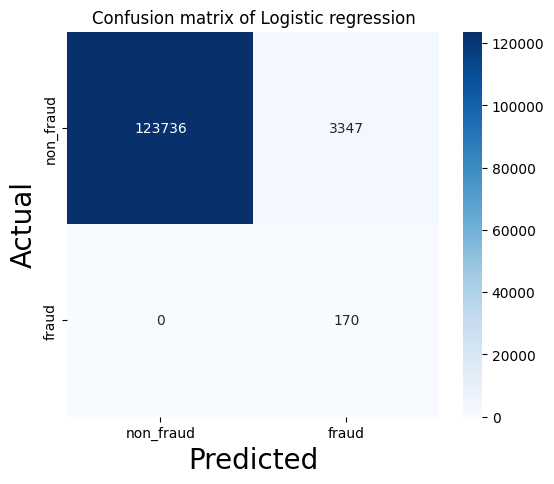

In [228]:
from sklearn.metrics import confusion_matrix, classification_report

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['non_fraud', 'fraud'], yticklabels=['non_fraud', 'fraud'])
ax.set_xlabel('Predicted', fontsize = 20); ax.set_ylabel('Actual', fontsize = 20)
plt.title("Confusion matrix of Logistic regression")
plt.show()

# Model Evaluation

In [229]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 score:  {f1:.4f}")

Accuracy:  0.9737
Recall:    1.0000
Precision: 0.0483
F1 score:  0.0922


1. ***Accuracy = 97.37%***
The model correctly classified 97.37% of all transactions.

2. ***Recall = 100%***
It did not miss any fraud cases, meaning there were no false negatives.
This is beneficial in fraud detection because failing to detect fraud can result in financial losses.

3. ***Precision = 4.83%***
Only 4.83% of the transactions predicted as fraudulent were actually fraudulent.
This means that 95.17% of the fraud alerts were false alarms (false positives).
This would overwhelm fraud investigators because almost every flagged transaction would turn out to be legitimate.

4. ***F1-score = 9.22%***
Although recall is perfect, the extremely low precision causes the F1-score to be very low.
This indicates that the model performs poorly overall in balancing fraud detection with minimizing false alarms.


# Training an XGBoost Algorithm to check if it's better

In [230]:
df_model = df.copy()

# One-hot encode transaction type
df_model = pd.get_dummies(df_model, columns=["type"], prefix="type")

# Drop identifiers that don't generalise (account numbers are not predictive features)
drop_cols = ["nameOrig", "nameDest"]
df_model = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

feature_cols = [c for c in df_model.columns if c not in [fraud_col, "isFlaggedFraud"]]
print(f"Number of features: {len(feature_cols)}")
feature_cols

Number of features: 15


['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'orig_balance_diff',
 'dest_balance_diff',
 'orig_emptied',
 'dest_was_empty',
 'type_CASH_IN',
 'type_CASH_OUT',
 'type_DEBIT',
 'type_PAYMENT',
 'type_TRANSFER']

# split the dataset into train and test sets

In [231]:
from sklearn.model_selection import train_test_split

X = df_model[feature_cols]
y = df_model[fraud_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())


Train fraud rate: 0.001333964625379905
Test fraud rate: 0.0013359213535240819


# Feature Importance Analysis

Feature importances (all features, ranked):
orig_balance_diff    0.411268
orig_emptied         0.268131
type_PAYMENT         0.215727
amount               0.037114
type_DEBIT           0.025732
oldbalanceOrg        0.010141
dest_was_empty       0.007023
dest_balance_diff    0.006513
type_CASH_OUT        0.005163
type_TRANSFER        0.004816
step                 0.003732
newbalanceDest       0.002401
oldbalanceDest       0.001380
newbalanceOrig       0.000859
type_CASH_IN         0.000000
dtype: float32


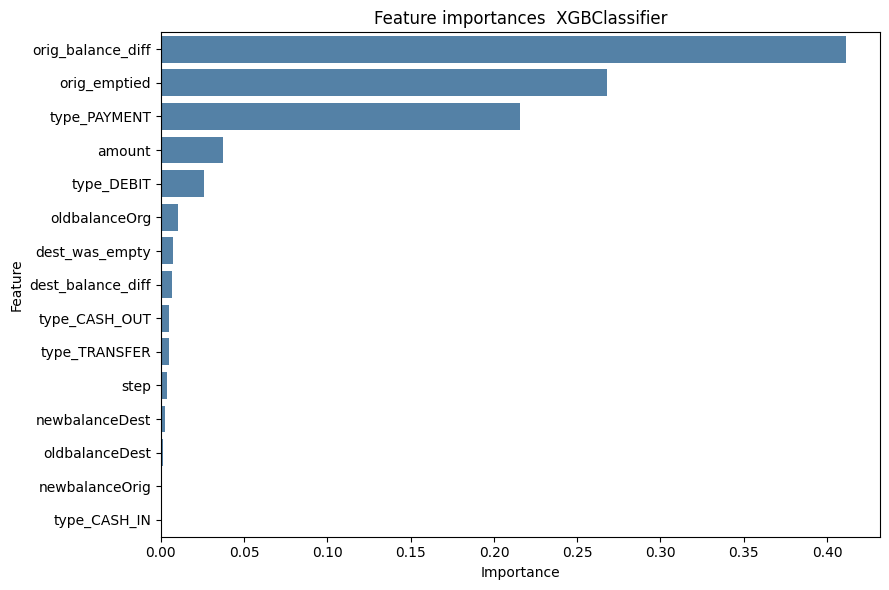

In [232]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Training the model first
from xgboost import XGBClassifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        scale_pos_weight=scale_pos_weight, eval_metric="aucpr", random_state=42)
model.fit(X_train, y_train)

# Extract importances and pair them with their feature names
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

# Print the full ranked list
print("Feature importances (all features, ranked):")
print(importances)


top_importances = importances.head(top_n)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, color="steelblue")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Feature importances  {type(model).__name__}")
plt.tight_layout()
plt.show()

# Model Evaluation

In [241]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

# 1. Generate predictions on the TEST set 
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  
# 2. Core metrics
print("=== XGBoost — Test Set Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()


=== XGBoost — Test Set Performance ===
Accuracy:  0.9994
Precision: 0.7333
Recall:    0.9059
F1 score:  0.8105
ROC-AUC:   0.9997



1. ***Accuracy = 0.9994 (99.94%)***
The model correctly classified 99.94% of all transactions.

2. ***Precision = 0.7333 (73.33%)***
Of all transactions that the model predicted as fraudulent, 73.33% were actually fraudulent.
The remaining 26.67% were false alarms (false positives).

3. ****Recall = 0.9059 (90.59%)***
The model successfully identified 90.59% of all actual fraudulent transactions.
It missed only about 9.41% of fraudulent cases

4. ***F1-Score = 0.8105 (81.05%)***
An F1-score of 81.05% indicates that the model achieves a good balance between correctly identifying fraud and minimizing false alarms.
This suggests that the classifier performs well on the minority (fraud) class.

5. ***ROC-AUC = 0.9997 (99.97%)***
The ROC-AUC score measures the model's ability to distinguish between fraudulent and non-fraudulent transactions across all classification thresholds.
A score of 0.9997 is extremely close to 1.0, indicating excellent discrimination between the two classes.

# Confusion matrix for XGBoost

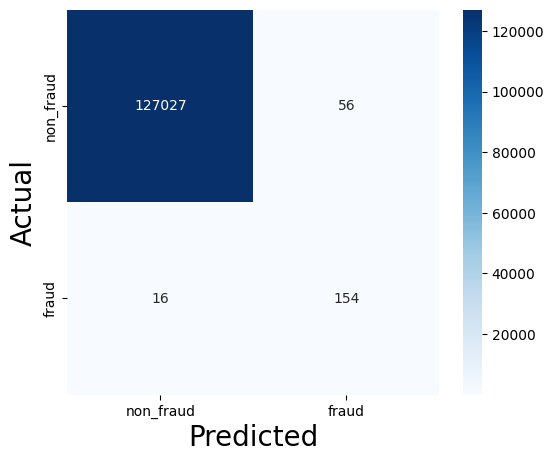

In [242]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['non_fraud', 'fraud'], yticklabels=['non_fraud', 'fraud'])
ax.set_xlabel('Predicted', fontsize = 20); ax.set_ylabel('Actual', fontsize = 20)
plt.show()

In [235]:
print(np.unique(y_pred, return_counts=True))

(array([0, 1]), array([127043,    210]))


# Classification Report

In [236]:
print("\nXGBoost:")
print(classification_report(y_test, y_pred, target_names=["non_fraud", "fraud"], digits=4))


XGBoost:
              precision    recall  f1-score   support

   non_fraud     0.9999    0.9996    0.9997    127083
       fraud     0.7333    0.9059    0.8105       170

    accuracy                         0.9994    127253
   macro avg     0.8666    0.9527    0.9051    127253
weighted avg     0.9995    0.9994    0.9995    127253



# Showing why Accuracy alone misleads

In [237]:
# Naive baseline: predict "not fraud" for every single transaction
naive_preds = np.zeros(len(y_test))

from sklearn.metrics import accuracy_score, recall_score, precision_score
naive_accuracy = accuracy_score(y_test, naive_preds)
naive_recall = recall_score(y_test, naive_preds, zero_division=0)

print(f"Naive 'always predict non-fraud' model:")
print(f"  Accuracy: {naive_accuracy:.4%}")
print(f"  Recall:   {naive_recall:.4%}")

Naive 'always predict non-fraud' model:
  Accuracy: 99.8664%
  Recall:   0.0000%


***This shows about 99.87% accuracy while catching 0% of fraud indicating that a model that does nothing useful still scores nearly as high as the real model real model's accuracy (99.994%). This proves that accuracy alone is meaningless here.***

# classification threshold using a business cost argument

Lowest-cost threshold: 0.03 (estimated cost: 5,980)


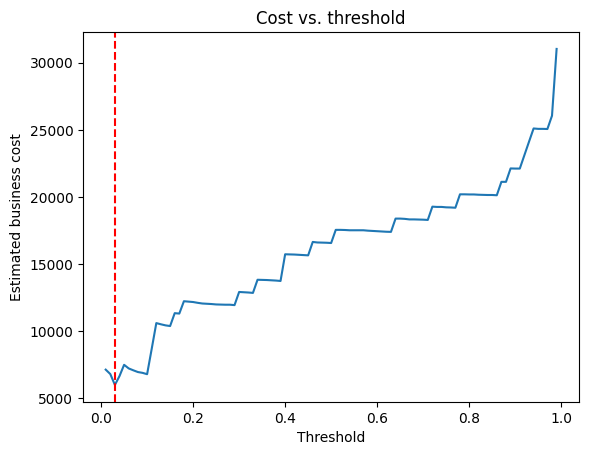

In [238]:
COST_FALSE_NEGATIVE = 1000   # <-- replace with a justified number (e.g., avg fraud amount from your EDA)
COST_FALSE_POSITIVE = 10     # <-- replace with a justified number (e.g., cost of manual review/customer friction)

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    total_cost = fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE
    costs.append(total_cost)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]
print(f"Lowest-cost threshold: {best_threshold:.2f} (estimated cost: {costs[best_idx]:,})")

plt.plot(thresholds, costs)
plt.axvline(best_threshold, color="red", linestyle="--")
plt.xlabel("Threshold"); plt.ylabel("Estimated business cost")
plt.title("Cost vs. threshold")
plt.show()

***The curve is lowest near the very start (threshold approximately 0.03) and rises steadily as the threshold increases, eventually shooting up sharply near threshold = 1.0
COST_FALSE_NEGATIVE is set much higher than COST_FALSE_POSITIVE. When missing fraud is assumed to be far more expensive than a false alarm, the math naturally pushes toward "flag almost everything, because even though that creates a lot of false positives, each one is cheap, while every fraud case you let through is expensive. The total cost stays low as long as you're not missing fraud.***

# CONCLUSION

***After training and comparing the two models, we selected XGBoost as the preferred model for fraud detection because it demonstrated significantly better overall performance than Logistic Regression. Although Logistic Regression achieved a perfect recall (100%), meaning it identified all fraudulent transactions, it had a very low precision (4.83%). This indicates that most transactions it classified as fraudulent were actually legitimate, resulting in a large number of false positives. Such a high false alarm rate would make the model impractical in a real-world fraud detection system, as it would waste resources investigating many legitimate transactions.**